In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Employee_Attrition_DataSet-selected-columns.csv")

In [3]:
df.head()

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4


In [4]:
df.shape

(10000, 10)

#### Information About the Dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        10000 non-null  str    
 1   Age               10000 non-null  int64  
 2   Department        10000 non-null  str    
 3   JobLevel          10000 non-null  int64  
 4   YearsAtCompany    10000 non-null  int64  
 5   MonthlyIncome     10000 non-null  int64  
 6   JobSatisfaction   10000 non-null  int64  
 7   WorkLifeBalance   10000 non-null  int64  
 8   OverTime          10000 non-null  str    
 9   DistanceFromHome  10000 non-null  float64
dtypes: float64(1), int64(6), str(3)
memory usage: 781.4 KB


#### Statistical Summary of the Dataset

In [6]:
df.describe()

,Age,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,37.693500,2.380800,7.788400,8967.918800,3.362100,2.761500,9.91074
std,9.376457,1.141368,7.141941,3500.745748,1.059951,0.893027,6.97463
min,22.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,1.00000
25%,31.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,4.70000
50%,37.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,8.30000
75%,44.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,13.40000
max,60.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,50.00000


#### Checking Missing Values

In [7]:
df.isnull().sum()

EmployeeID          0
Age                 0
Department          0
JobLevel            0
YearsAtCompany      0
MonthlyIncome       0
JobSatisfaction     0
WorkLifeBalance     0
OverTime            0
DistanceFromHome    0
dtype: int64

#### Checking Duplicate Records

In [8]:
df.duplicated().sum()

np.int64(0)

#### Removing the EmployeeID Column

In [9]:
df = df.drop('EmployeeID', axis=1)

### Targeted Variable Analysis

#### Checking Class Balance

In [10]:
df['OverTime'].value_counts()

OverTime
No     7151
Yes    2849
Name: count, dtype: int64

### Univariate analysis

#### Distribution of Numerical Features

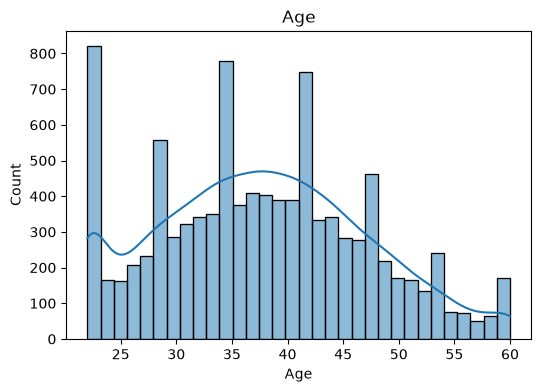

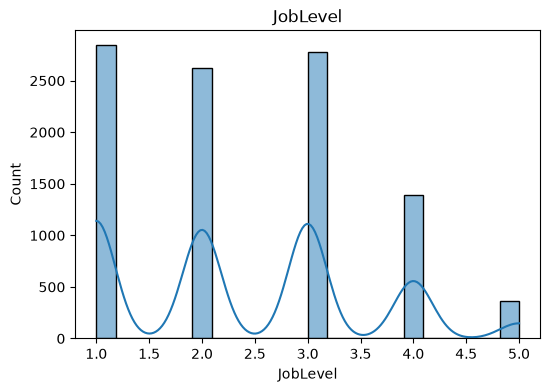

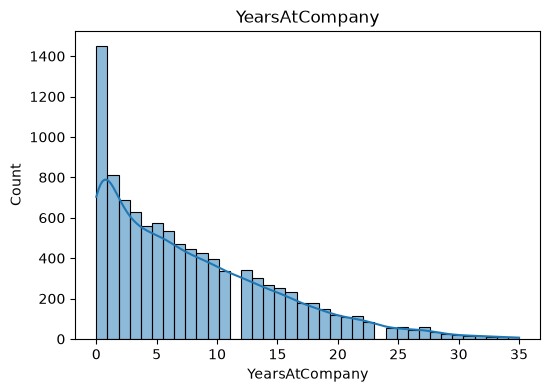

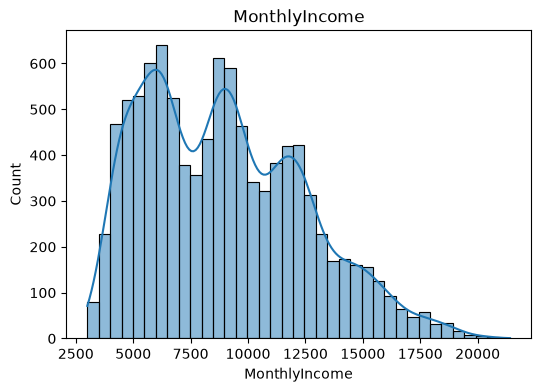

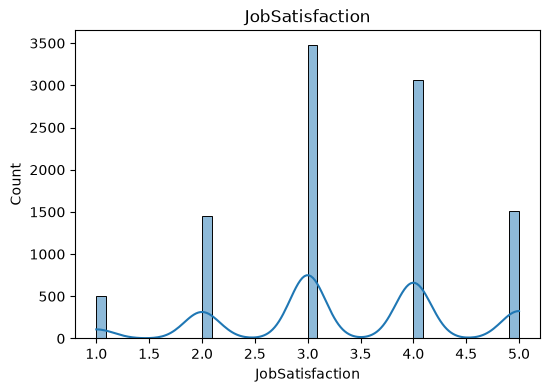

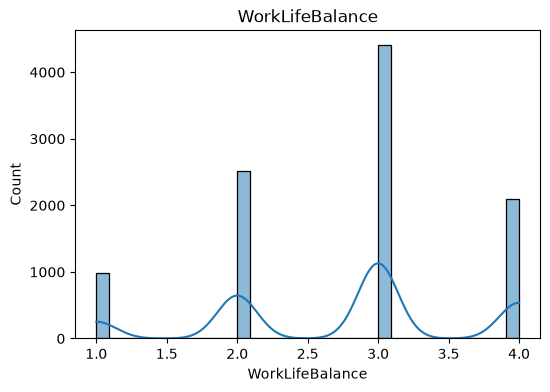

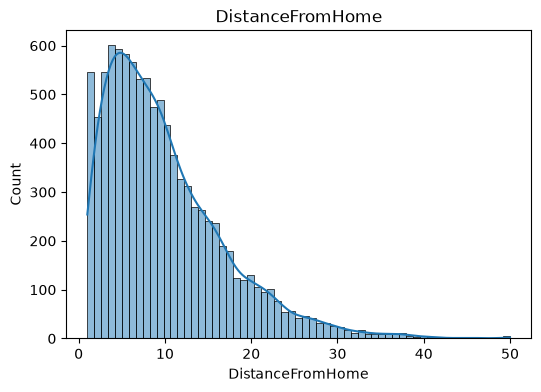

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64'])

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(x=df[col], kde=True)
    plt.title(col)
    plt.show()

#### Categorical Feature Analysis

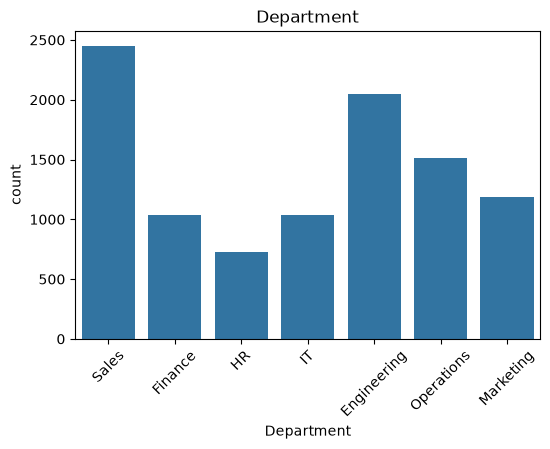

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['Department'])
plt.title("Department")
plt.xticks(rotation=45)
plt.show()

### Bivariate Analysis 

#### Encoding the Target Variable OverTime

In [13]:
df['OverTime'] = df['OverTime'].apply(
    lambda x: 1 if x == 'Yes' else 0
)

#### Correlation Analysis with the Target Variable

In [14]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['OverTime'].sort_values(ascending=False)

OverTime            1.000000
MonthlyIncome       0.039676
JobLevel            0.017296
YearsAtCompany      0.011939
JobSatisfaction     0.005932
WorkLifeBalance     0.004338
Age                -0.000704
DistanceFromHome   -0.009848
Name: OverTime, dtype: float64

#### Comparative Analysis of Numerical Features by Target Class

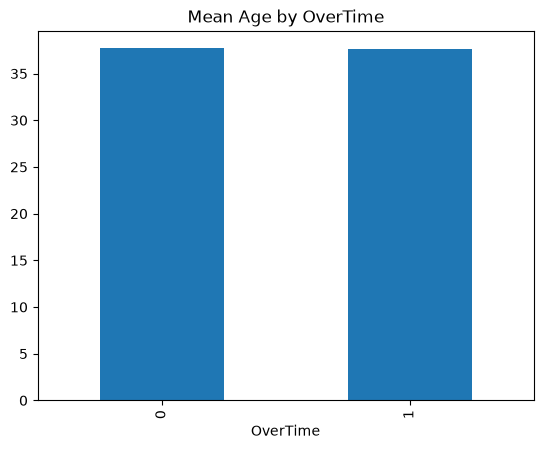

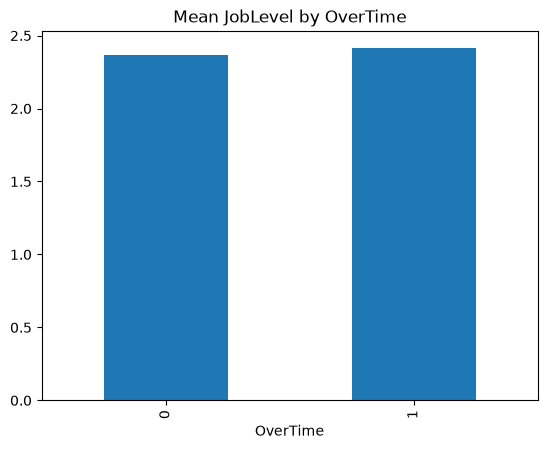

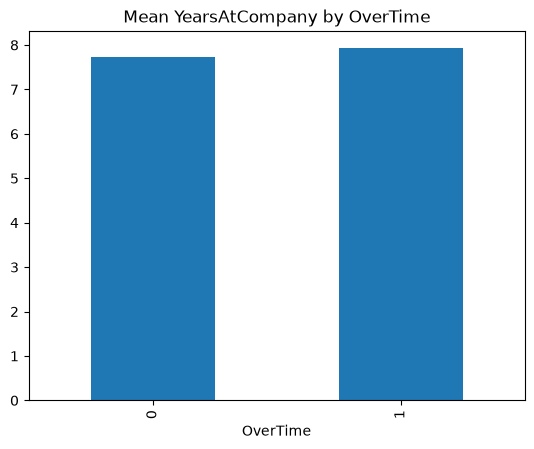

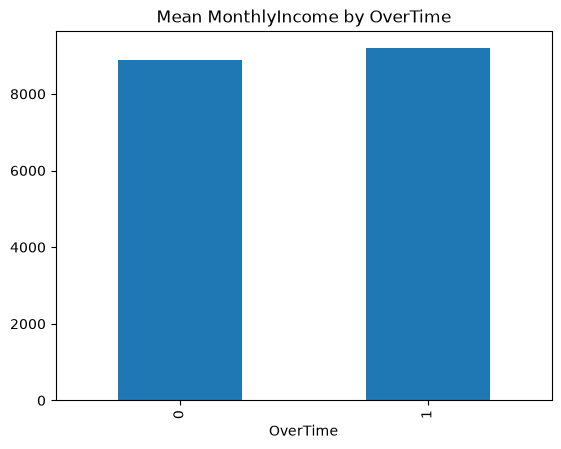

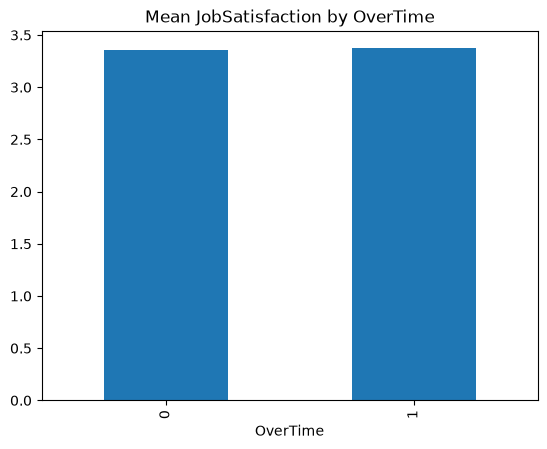

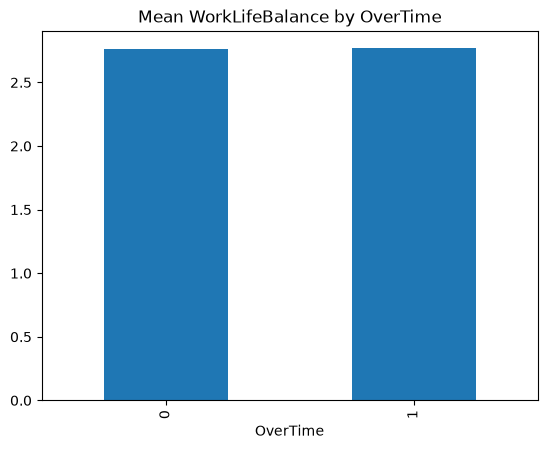

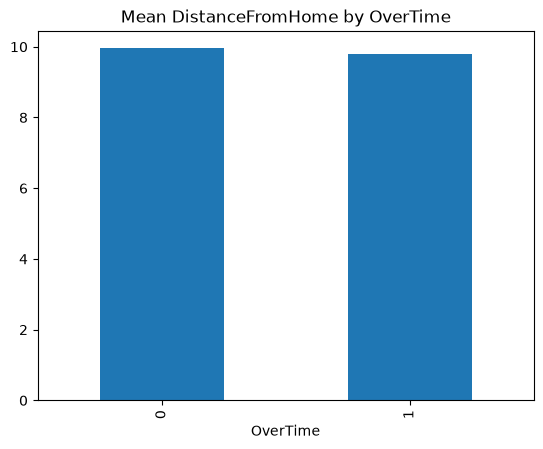

In [15]:
for col in df.select_dtypes(include=['int64', 'float64']).columns.drop('OverTime'):
    df.groupby('OverTime')[col].mean().plot(kind='bar')
    plt.title(f"Mean {col} by OverTime")
    plt.show()

#### Correlation Matrix of Numerical Features

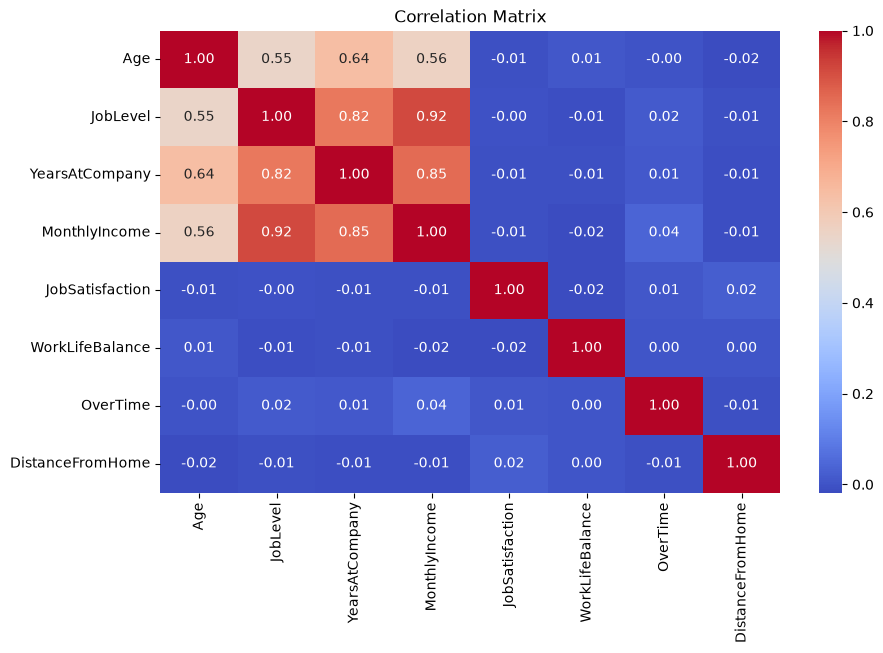

In [16]:
plt.figure(figsize=(10, 6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

#### Department-wise OverTime Rate Analysis

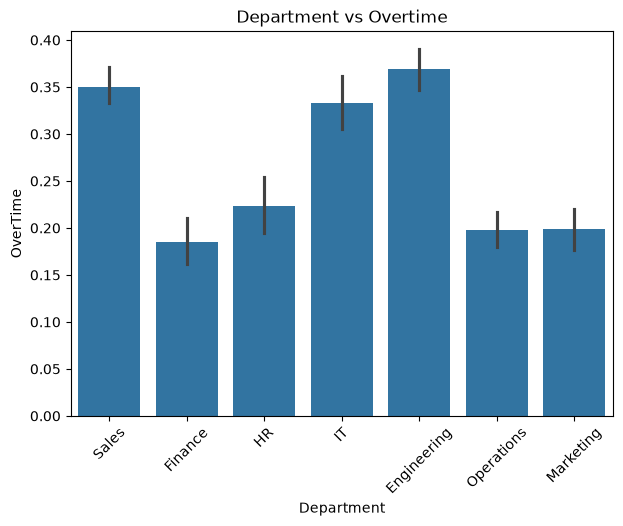

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(x=df['Department'], y=df['OverTime'])
plt.title("Department vs Overtime")
plt.xticks(rotation=45)
plt.show()

#### Outlier Analysis of Numerical Features

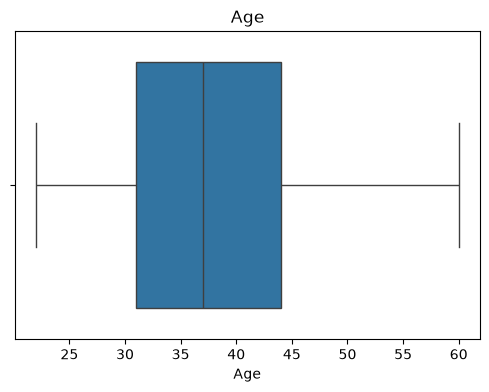

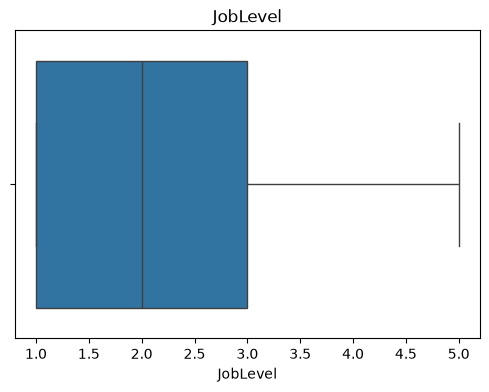

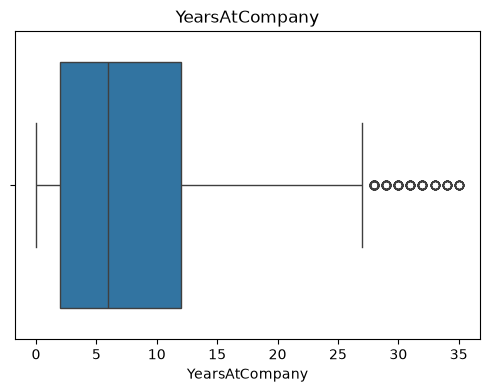

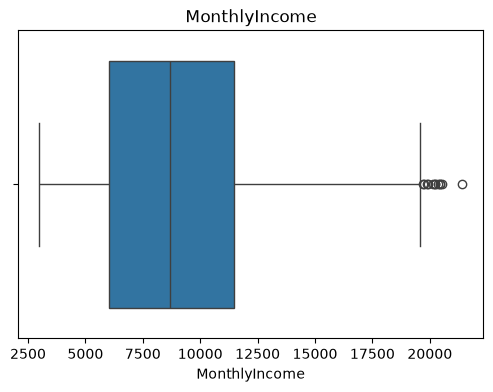

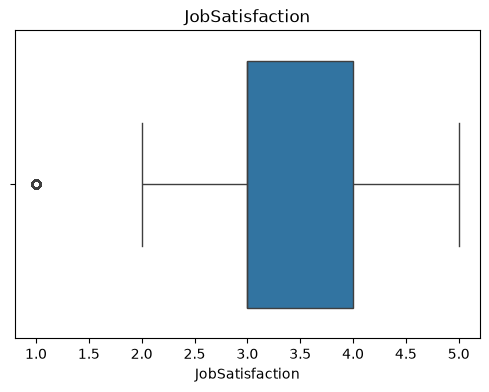

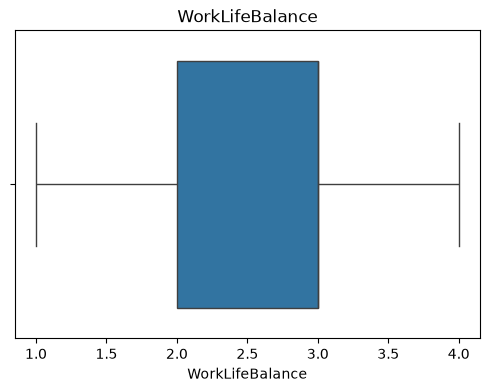

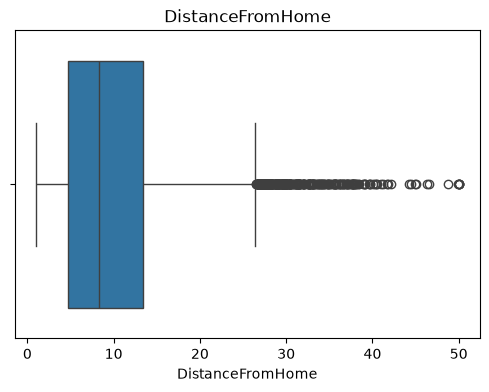

In [18]:
for col in df.select_dtypes(include=['int64', 'float64']).columns.drop('OverTime'):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Outlier Treatment Using IQR Clipping

In [19]:
num_cols = ['YearsAtCompany', 'MonthlyIncome', 'JobSatisfaction', 'DistanceFromHome']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

#### Verification After Outlier Treatment

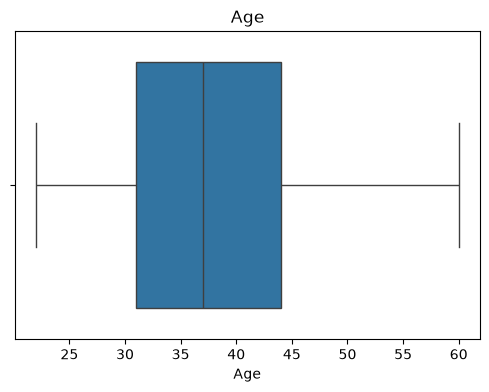

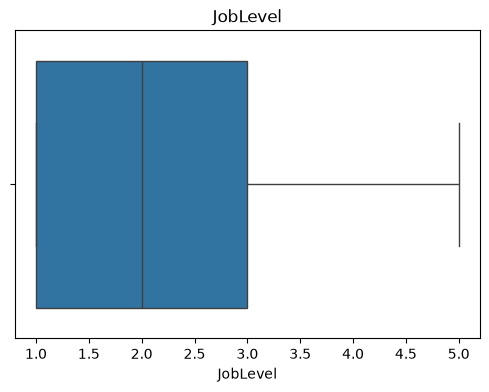

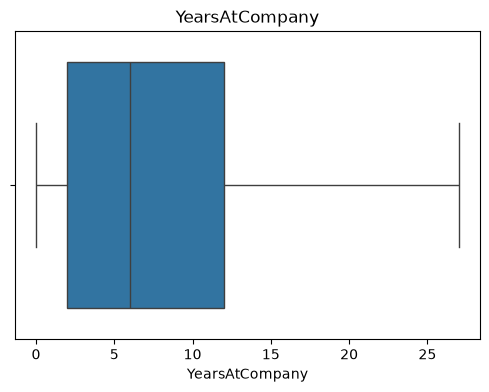

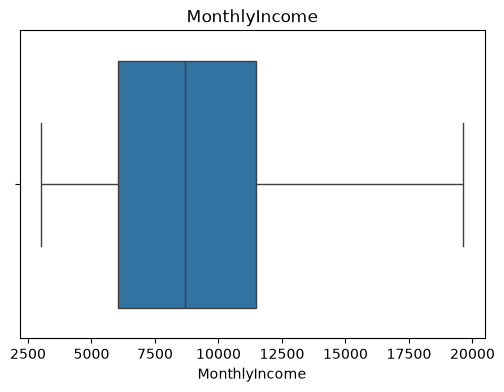

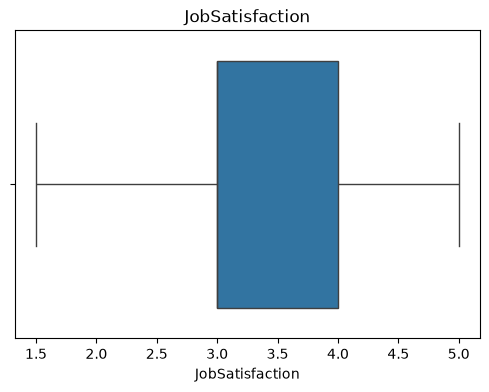

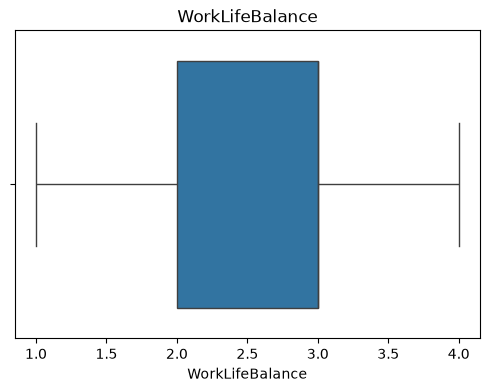

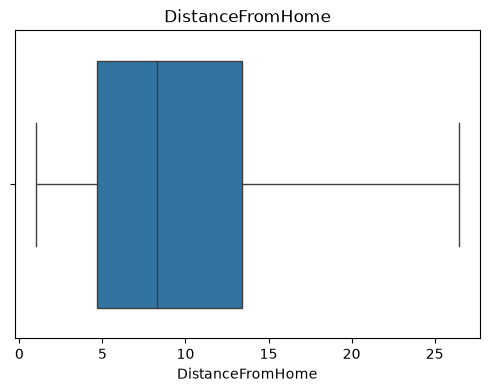

In [20]:
for col in df.select_dtypes(include=['int64', 'float64']).columns.drop('OverTime'):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

#### Splitting Data into Features (X) and Target (y)

In [21]:
X = df.drop("OverTime", axis=1)

y = df["OverTime"]

#### Encoding Categorical Features Using One-Hot Encoding

In [22]:
X = pd.get_dummies(X, columns=['Department'], drop_first=True)

#### Converting Boolean Features into Integer Format

In [23]:
X = X.astype({col: 'int' for col in X.select_dtypes(include=['bool']).columns})

#### Splitting Data into Training and Testing Sets

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.20, random_state=42
)

#### Feature Scaling Using StandardScaler

In [25]:
from sklearn.preprocessing import StandardScaler

cols = ['Age', 'JobLevel', 'YearsAtCompany', 'MonthlyIncome',
       'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])

## Logistic Regression

#### Training Logistic Regression Model

In [26]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#### Logistic Regression Prediction

In [27]:
y_pred_lr = lr_model.predict(X_test_scaled)

#### Logistic Regression Evaluation

Accuracy Score: 0.7255


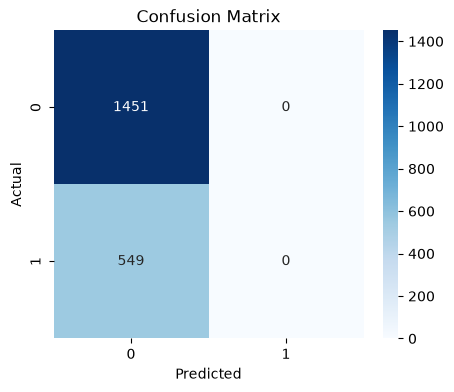


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cr_lr = classification_report(y_test, y_pred_lr, zero_division=0)

# Accuracy
print("Accuracy Score:", as_lr)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lr)

#### ROC-AUC Curve

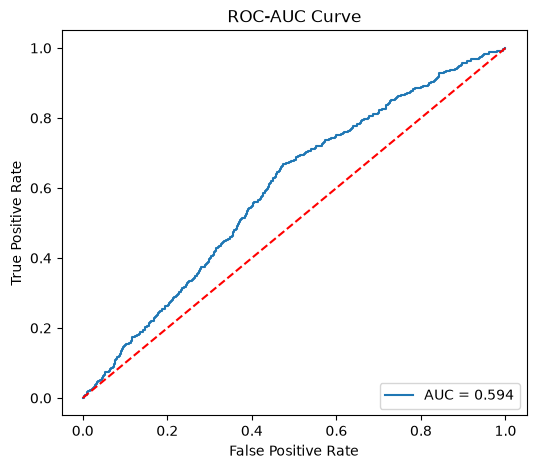

ROC-AUC Score: 0.5943454611416786


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_lr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## Decision Tree

#### Decision Tree Training

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### Decision Tree Prediction

In [31]:
y_pred_dt = dt_model.predict(X_test)

#### Decision Tree Evaluation

Accuracy Score: 0.589


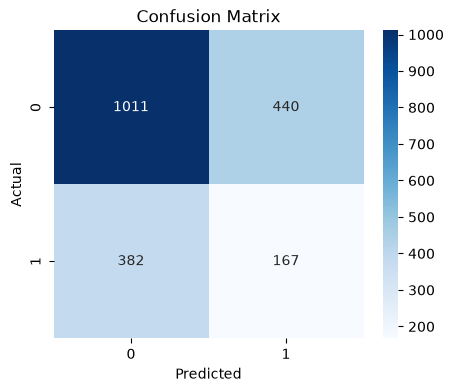


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.70      0.71      1451
           1       0.28      0.30      0.29       549

    accuracy                           0.59      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.60      0.59      0.60      2000



In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cr_dt = classification_report(y_test, y_pred_dt)

# Accuracy
print("Accuracy Score:", as_dt)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_dt)

#### Decision Tree ROC-AUC Curve

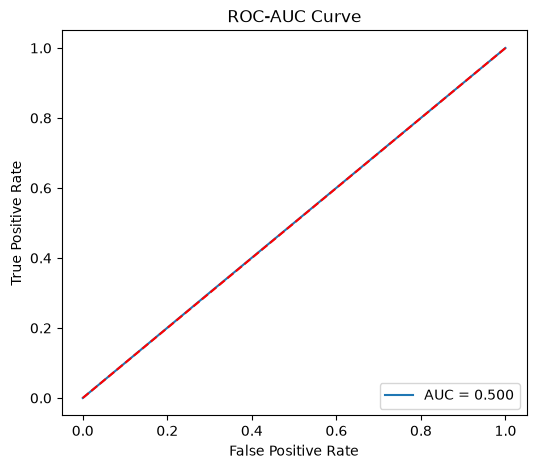

ROC-AUC Score: 0.5004751449600112


In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# AUC Score
roc_score = roc_auc_score(y_test, y_prob_dt)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", roc_score)

## Random Forest

#### Random Forest Training

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Random Forest Prediction

In [35]:
y_pred_rf = rf_model.predict(X_test)

#### Random Forest Evaluation

Accuracy Score: 0.707


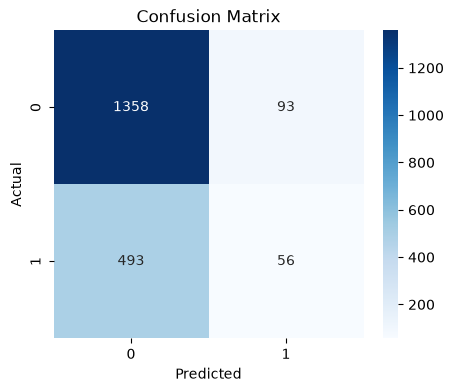


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.94      0.82      1451
           1       0.38      0.10      0.16       549

    accuracy                           0.71      2000
   macro avg       0.55      0.52      0.49      2000
weighted avg       0.64      0.71      0.64      2000



In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf)

# Accuracy
print("Accuracy Score:", as_rf)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_rf)

#### Random Forest ROC-AUC Curve

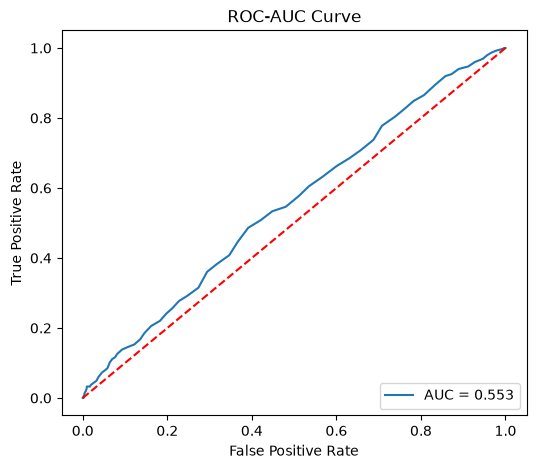

ROC-AUC Score: 0.5534396854628238


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_prob_rf)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## Gradient Boosting

#### Gradient Boosting Training

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

#### Gradient Boosting Prediction

In [39]:
y_pred_gb = gb_model.predict(X_test)

#### Gradient Boosting Evaluation

Accuracy Score: 0.7255


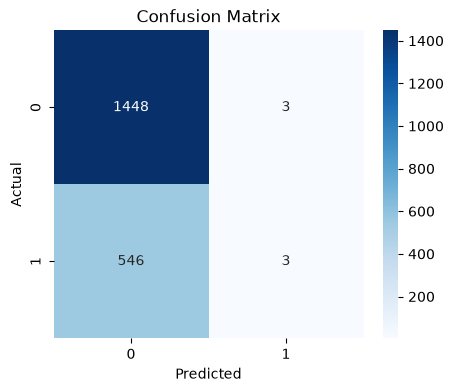


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.50      0.01      0.01       549

    accuracy                           0.73      2000
   macro avg       0.61      0.50      0.43      2000
weighted avg       0.66      0.73      0.61      2000



In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)
cr_gb = classification_report(y_test, y_pred_gb)

# Accuracy
print("Accuracy Score:", as_gb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gb)

#### Gradient Boosting ROC-AUC Curve

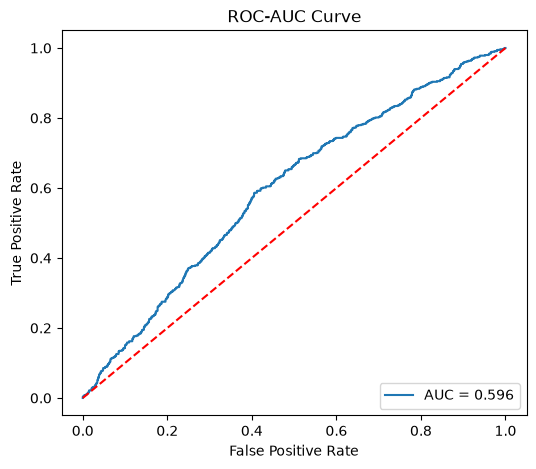

ROC-AUC Score: 0.5961951998433339


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_gb)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## XGBoost

#### XGBoost Training

In [42]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


#### XGBoost Prediction

In [43]:
y_pred_xgb = xgb_model.predict(X_test)

#### XGBoost Evaluation

Accuracy Score: 0.6935


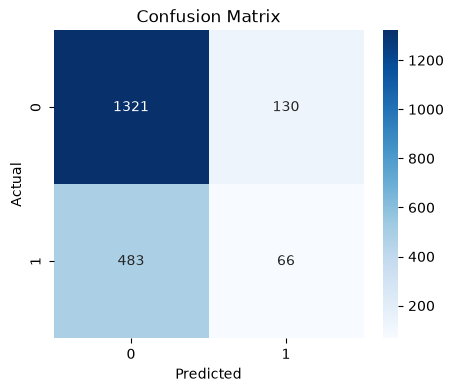


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81      1451
           1       0.34      0.12      0.18       549

    accuracy                           0.69      2000
   macro avg       0.53      0.52      0.49      2000
weighted avg       0.62      0.69      0.64      2000



In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_xgb = accuracy_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cr_xgb = classification_report(y_test, y_pred_xgb)

# Accuracy
print("Accuracy Score:", as_xgb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_xgb)

#### XGBoost ROC-AUC Curve

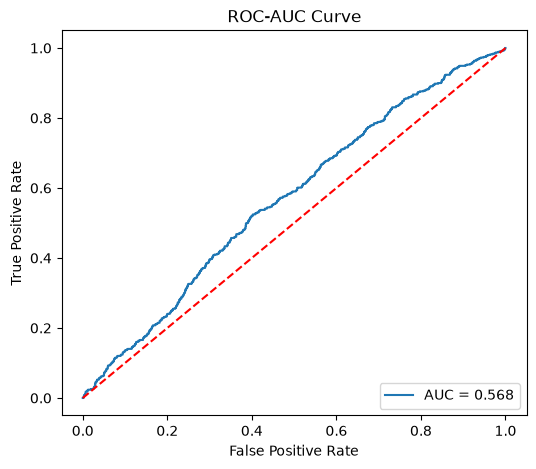

ROC-AUC Score: 0.5680455285532621


In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_xgb)

# Plots
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## LightGBM

#### LightGBM Training

In [46]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(verbose=-1,
                            random_state=42
                           )

lgbm_model.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


#### LightGBM Prediction

In [47]:
y_pred_lgbm = lgbm_model.predict(X_test)

#### LightGBM Evaluation

Accuracy Score: 0.7195


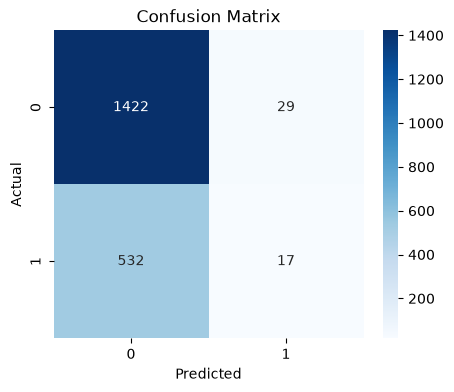


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.98      0.84      1451
           1       0.37      0.03      0.06       549

    accuracy                           0.72      2000
   macro avg       0.55      0.51      0.45      2000
weighted avg       0.63      0.72      0.62      2000



In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lgbm = accuracy_score(y_test, y_pred_lgbm)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
cr_lgbm = classification_report(y_test, y_pred_lgbm)

# Accuracy
print("Accuracy Score:", as_lgbm)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lgbm)

#### LightGBM ROC-AUC Curve

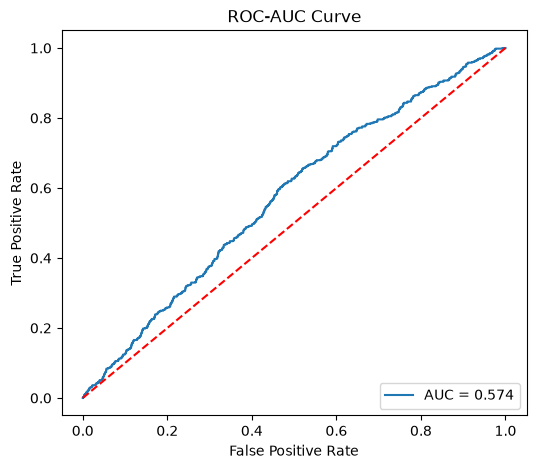

ROC-AUC Score: 0.5742945948965539


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgbm)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_lgbm)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## CatBoost

#### CatBoost Training

In [50]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(verbose=0,
                              random_state=42
                             )

cb_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

#### CatBoost Prediction

In [51]:
y_pred_cb = cb_model.predict(X_test)

#### CatBoost Evaluation

Accuracy Score: 0.729


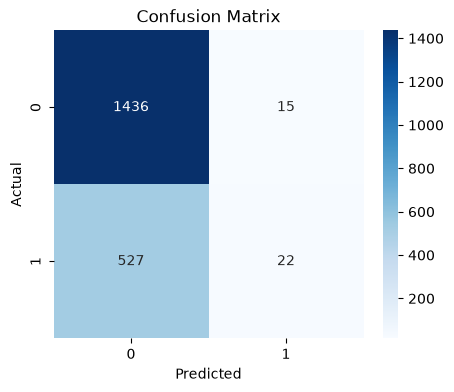


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.99      0.84      1451
           1       0.59      0.04      0.08       549

    accuracy                           0.73      2000
   macro avg       0.66      0.51      0.46      2000
weighted avg       0.69      0.73      0.63      2000



In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_cb = accuracy_score(y_test, y_pred_cb)
cm_cb = confusion_matrix(y_test, y_pred_cb)
cr_cb = classification_report(y_test, y_pred_cb)

# Accuracy
print("Accuracy Score:", as_cb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_cb, annot=True, cmap='Blues', fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_cb)

#### CatBoost ROC-AUC Curve

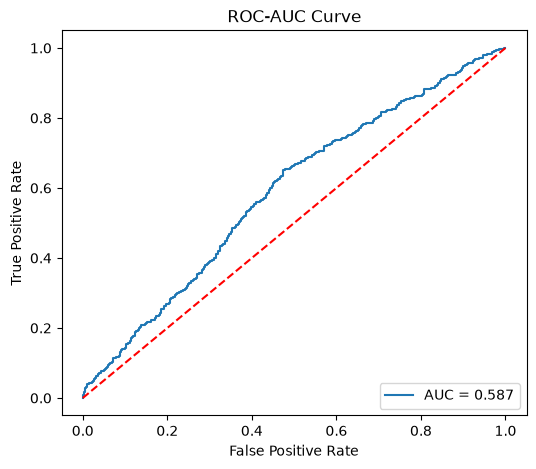

ROC-AUC Score: 0.5874850458009613


In [53]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_cb = cb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_cb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## K-Nearest Neighbors (KNN) 

#### KNN Training

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### KNN Prediction

In [55]:
y_pred_knn = knn_model.predict(X_test_scaled)

#### KNN Evaluation

Accuracy Score: 0.6635


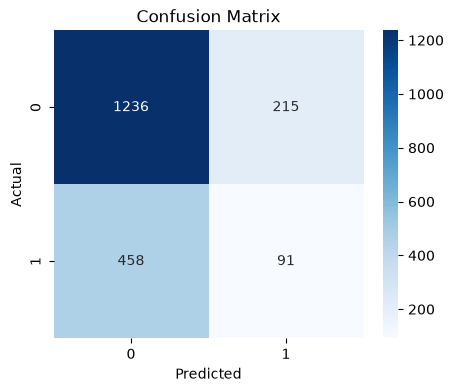


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.85      0.79      1451
           1       0.30      0.17      0.21       549

    accuracy                           0.66      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.61      0.66      0.63      2000



In [56]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cr_knn = classification_report(y_test, y_pred_knn)

# Accuracy
print("Accuracy Score:", as_knn)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_knn)

#### KNN ROC-AUC Curve

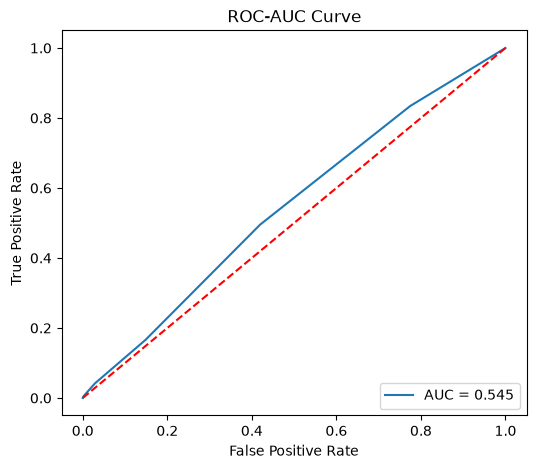

ROC-AUC Score: 0.545447584041657


In [57]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_knn)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## Support Vector Machine (SVM) 

In [58]:
from sklearn.svm import SVC

svc_model = SVC(probability=True, random_state=42)
svc_model.fit(X_train_scaled, y_train)

C:\Users\Akhlaque Alam\ml_new\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


#### SVM Prediction

In [59]:
y_pred_svc = svc_model.predict(X_test_scaled)

#### SVM Evaluation

Accuracy Score: 0.7255


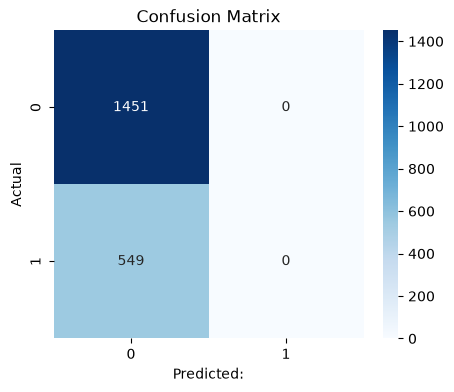


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [60]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_svc = accuracy_score(y_test, y_pred_svc)
cm_svc = confusion_matrix(y_test, y_pred_svc)
cr_svc = classification_report(y_test, y_pred_svc, zero_division=0)

# Accuracy
print("Accuracy Score:", as_svc)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted:")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_svc)

#### SVM ROC-AUC Curve

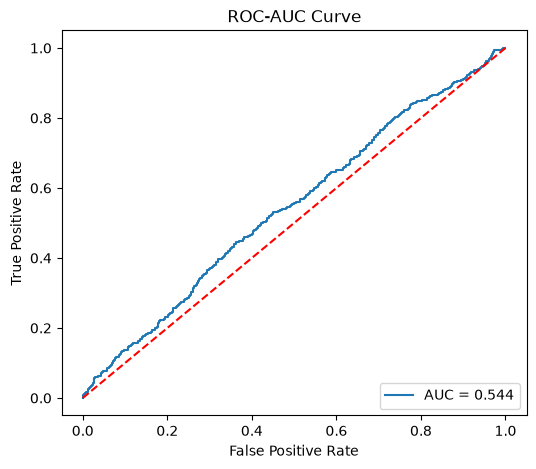

ROC-AUC Score: 0.5437189853364114


In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_svc = svc_model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svc)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_svc)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## Gaussian Naive Bayes 

#### Gaussian NB Training

In [62]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[5700.,2300.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.71,0.29]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.01235
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Age','JobLevel','YearsAtCompany',...,'Department_Marketing', 'Department_Operations','Department_Sales']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[37.77, 2.38, 7.75,..., 0.13, 0.17, 0.23], [37.68, 2.4 , 7.79,..., 0.08, 0.1 , 0.3 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[87.45, 1.32,48.97,..., 0.13, 0.15, 0.19], [88.58, 1.35,48.87,..., 0.09, 0.1 , 0.22]]"


#### Gaussian NB Prediction

In [63]:
y_pred_gnb = gnb_model.predict(X_test)

#### Gaussian NB Evaluation

Accuracy Score: 0.6215


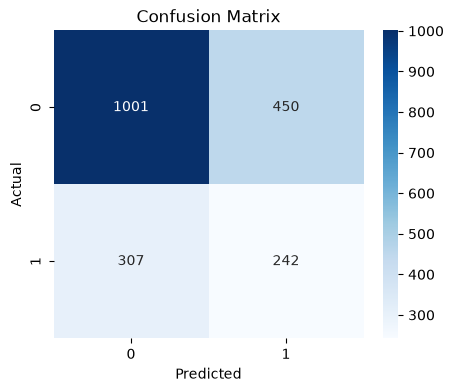


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73      1451
           1       0.35      0.44      0.39       549

    accuracy                           0.62      2000
   macro avg       0.56      0.57      0.56      2000
weighted avg       0.65      0.62      0.63      2000



In [64]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gnb = accuracy_score(y_test, y_pred_gnb)
cm_gnb = confusion_matrix(y_test, y_pred_gnb)
cr_gnb = classification_report(y_test, y_pred_gnb)

# Accuracy
print("Accuracy Score:", as_gnb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gnb)

#### Gaussian NB ROC-AUC Curve

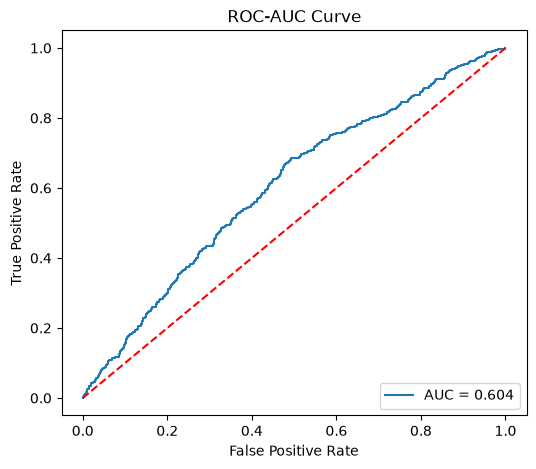

ROC-AUC Score: 0.6041144917329799


In [65]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_gnb = gnb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gnb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_gnb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## AdaBoost

#### AdaBoost Training

In [66]:
from sklearn.ensemble import AdaBoostClassifier

adb_model = AdaBoostClassifier(random_state=42)
adb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.29,0.47,0.48,...,0.49,0.49,0.49]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.91,0.13,0.1 ,...,0.04,0.02,0.05]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.01,0. ,0.04,...,0.13,0.4 ,0.06]"


#### AdaBoost Prediction

In [67]:
y_pred_adb = adb_model.predict(X_test)

#### AdaBoost Evaluation

Accuracy Score: 0.7255


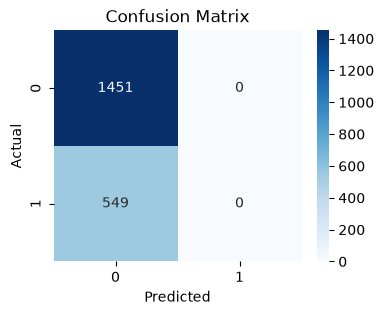


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [68]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_adb = accuracy_score(y_test, y_pred_adb)
cm_adb = confusion_matrix(y_test, y_pred_adb)
cr_adb = classification_report(y_test, y_pred_adb, zero_division=0)

# Accuracy
print("Accuracy Score:", as_adb)

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_adb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_adb)

#### AdaBoost ROC-AUC Curve

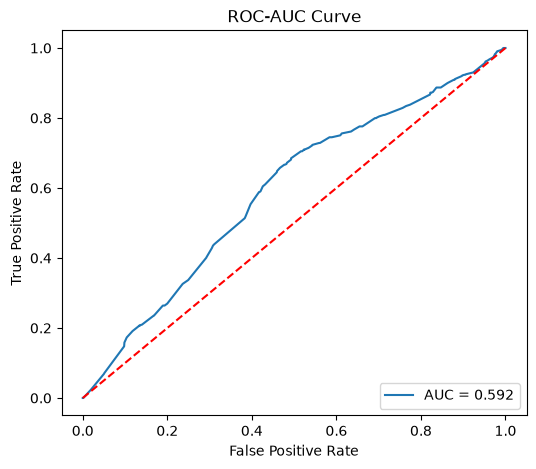

ROC-AUC Score: 0.5917324776958043


In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_adb = adb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_adb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_adb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## Extra Trees

#### Extra Trees Training

In [70]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` 

#### Extra Trees Prediction

In [71]:
y_pred_et = et_model.predict(X_test)

#### Extra Trees Evaluation

Accuracy Score: 0.685


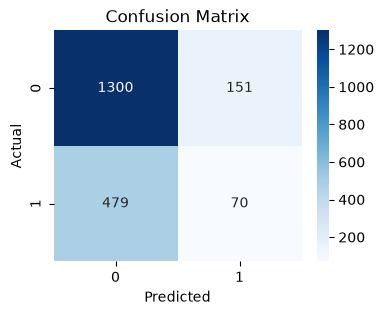


Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.90      0.80      1451
           1       0.32      0.13      0.18       549

    accuracy                           0.69      2000
   macro avg       0.52      0.51      0.49      2000
weighted avg       0.62      0.69      0.63      2000



In [72]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_et = accuracy_score(y_test, y_pred_et)
cm_et = confusion_matrix(y_test, y_pred_et)
cr_et = classification_report(y_test, y_pred_et)

# Accuracy
print("Accuracy Score:", as_et)

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_et, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_et)

#### Extra Trees ROC-AUC Curve

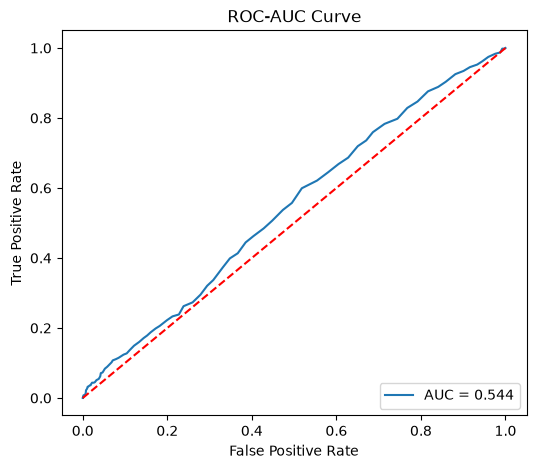

ROC-AUC Score: 0.5435614405742414


In [73]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_et = et_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_et)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_et)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

In [74]:
from sklearn.metrics import classification_report

cr_lr_dict   = classification_report(y_test, y_pred_lr, output_dict=True, zero_division=0)
cr_dt_dict   = classification_report(y_test, y_pred_dt, output_dict=True, zero_division=0)
cr_rf_dict   = classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0)
cr_gb_dict   = classification_report(y_test, y_pred_gb, output_dict=True, zero_division=0)
cr_xgb_dict  = classification_report(y_test, y_pred_xgb, output_dict=True, zero_division=0)
cr_lgbm_dict = classification_report(y_test, y_pred_lgbm, output_dict=True, zero_division=0)
cr_cb_dict   = classification_report(y_test, y_pred_cb, output_dict=True, zero_division=0)
cr_knn_dict  = classification_report(y_test, y_pred_knn, output_dict=True, zero_division=0)
cr_svc_dict  = classification_report(y_test, y_pred_svc, output_dict=True, zero_division=0)
cr_gnb_dict  = classification_report(y_test, y_pred_gnb, output_dict=True, zero_division=0)
cr_adb_dict  = classification_report(y_test, y_pred_adb, output_dict=True, zero_division=0)
cr_et_dict   = classification_report(y_test, y_pred_et, output_dict=True, zero_division=0)

# Comparison
comparison = pd.DataFrame ({
    'Model': [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "KNN",
        "SVM",
        "GNB",
        "AdaBoost",
        "Extra Trees"
    ],
    'Accuracy': [
        as_lr,
        as_dt,
        as_rf,
        as_gb,
        as_xgb,
        as_lgbm,
        as_cb,
        as_knn,
        as_svc,
        as_gnb,
        as_adb,
        as_et
    ],
    'Precision': [
        cr_lr_dict["weighted avg"]["precision"],
        cr_dt_dict["weighted avg"]["precision"],
        cr_rf_dict["weighted avg"]["precision"],
        cr_gb_dict["weighted avg"]["precision"],
        cr_xgb_dict["weighted avg"]["precision"],
        cr_lgbm_dict["weighted avg"]["precision"],
        cr_cb_dict["weighted avg"]["precision"],
        cr_knn_dict["weighted avg"]["precision"],
        cr_svc_dict["weighted avg"]["precision"],
        cr_gnb_dict["weighted avg"]["precision"],
        cr_adb_dict["weighted avg"]["precision"],
        cr_et_dict["weighted avg"]["precision"]
    ],
    'Recall': [
        cr_lr_dict["weighted avg"]["recall"],
        cr_dt_dict["weighted avg"]["recall"],
        cr_rf_dict["weighted avg"]["recall"],
        cr_gb_dict["weighted avg"]["recall"],
        cr_xgb_dict["weighted avg"]["recall"],
        cr_lgbm_dict["weighted avg"]["recall"],
        cr_cb_dict["weighted avg"]["recall"],
        cr_knn_dict["weighted avg"]["recall"],
        cr_svc_dict["weighted avg"]["recall"],
        cr_gnb_dict["weighted avg"]["recall"],
        cr_adb_dict["weighted avg"]["recall"],
        cr_et_dict["weighted avg"]["recall"]
    ],
    'F1-Score': [
        cr_lr_dict["weighted avg"]["f1-score"],
        cr_dt_dict["weighted avg"]["f1-score"],
        cr_rf_dict["weighted avg"]["f1-score"],
        cr_gb_dict["weighted avg"]["f1-score"],
        cr_xgb_dict["weighted avg"]["f1-score"],
        cr_lgbm_dict["weighted avg"]["f1-score"],
        cr_cb_dict["weighted avg"]["f1-score"],
        cr_knn_dict["weighted avg"]["f1-score"],
        cr_svc_dict["weighted avg"]["f1-score"],
        cr_gnb_dict["weighted avg"]["f1-score"],
        cr_adb_dict["weighted avg"]["f1-score"],
        cr_et_dict["weighted avg"]["f1-score"]
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm),
        roc_auc_score(y_test, y_prob_cb),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_svc),
        roc_auc_score(y_test, y_prob_gnb),
        roc_auc_score(y_test, y_prob_adb),
        roc_auc_score(y_test, y_prob_et)
    ]
})

comparison = comparison.sort_values(by="ROC-AUC", ascending=False).round(4)
comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
9,GNB,0.6215,0.6512,0.6215,0.6335,0.6041
3,Gradient Boosting,0.7255,0.6641,0.7255,0.6129,0.5962
0,Logistic Regression,0.7255,0.5264,0.7255,0.6101,0.5943
10,AdaBoost,0.7255,0.5264,0.7255,0.6101,0.5917
6,CatBoost,0.7290,0.6939,0.7290,0.6309,0.5875
5,LightGBM,0.7195,0.6294,0.7195,0.6217,0.5743
4,XGBoost,0.6935,0.6237,0.6935,0.6375,0.5680
2,Random Forest,0.7070,0.6354,0.7070,0.6408,0.5534
7,KNN,0.6635,0.6110,0.6635,0.6287,0.5454
8,SVM,0.7255,0.5264,0.7255,0.6101,0.5437


#### CatBoost Hyperparameter Tuning

In [75]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

# Base Model
cb = CatBoostClassifier(
    random_state=42,
    verbose=0
)

# Hyperparameter Grid
param_dist = {
    'iterations': [200, 300, 500, 700, 1000],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'depth': [4, 5, 6, 7, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9, 11],
    'border_count': [32, 64, 128, 254],
    'bagging_temperature': [0, 0.5, 1, 2, 3, 5]
}

# Randomized Search
random_search_cb = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_cb.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search_cb.best_params_)
print("Best ROC-AUC Score:", random_search_cb.best_score_)

Best Parameters: {'learning_rate': 0.01, 'l2_leaf_reg': 11, 'iterations': 300, 'depth': 7, 'border_count': 64, 'bagging_temperature': 2}
Best ROC-AUC Score: 0.5930118230358505


#### Tuned CatBoost Model Training

In [121]:
cb_tuned = CatBoostClassifier (
    learning_rate=0.01,
    l2_leaf_reg=11,
    iterations=300,
    depth=7,
    border_count=64,
    bagging_temperature=2,
    random_state=42,
    verbose=0
)

cb_tuned.fit(X_train, y_train)

CatBoostClassifier(bagging_temperature=2, border_count=64, depth=7, iterations=300, l2_leaf_reg=11, learning_rate=0.01, random_state=42, verbose=0)

#### Tuned CatBoost Prediction

In [122]:
y_pred_cb_tuned = cb_tuned.predict(X_test)

#### Tuned CatBoost Model Evaluation

Accuracy Score: 0.7255


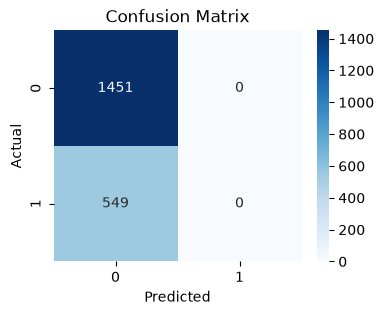


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [123]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_cb_tuned = accuracy_score(y_test, y_pred_cb_tuned)
cm_cb_tuned = confusion_matrix(y_test, y_pred_cb_tuned)
cr_cb_tuned = classification_report(y_test, y_pred_cb_tuned, zero_division=0)

# Accuracy
print("Accuracy Score:", as_cb_tuned)

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_cb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_cb_tuned)

#### Tuned CatBoost ROC-AUC Curve

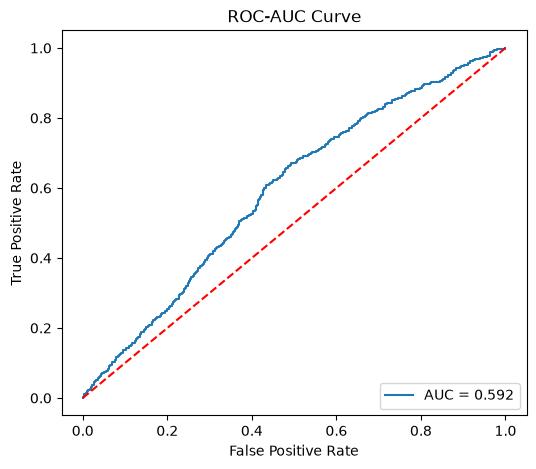

ROC-AUC Score: 0.5919979814185053


In [124]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Posative class
y_prob_cb_tuned = cb_tuned.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_cb_tuned)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### Gradient Boosting Hyperparameter Tuning

In [125]:
from sklearn.model_selection import RandomizedSearchCV

# Base Model
gb = GradientBoostingClassifier(random_state=42)

# Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

# Randomized Search
random_search_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_gb.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search_gb.best_params_)
print("Best ROC-AUC Score:", random_search_gb.best_score_)

Best Parameters: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.01}
Best ROC-AUC Score: 0.5954454614797864


#### Tuned Gradient Boosting Model Training

In [126]:
gb_tuned = GradientBoostingClassifier(
    subsample=0.7,
    n_estimators=200,
    min_samples_split=15,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)

gb_tuned.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: {'sqrt', 'log2'}, int or float, default=NoneThe number of features to consider when looking for the best split:- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0]` and the features considered at each split will be `max(1, int(max_features * n_features_in_))`.- If 'sqrt', then `max_features=sqrt(n_features)`.- If 'log2', then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Choosing `max_features < n_features` leads to a reduction of varianceand an increase in bias.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'fri

#### Tuned Gradient Boosting Prediction

In [127]:
y_pred_gb_tuned = gb_tuned.predict(X_test)

#### Tuned Gradient Boosting Model Evaluation

Accuracy Score: 0.7255


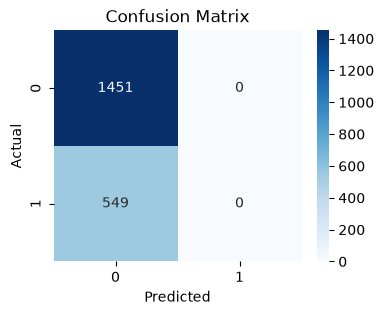


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [128]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gb_tuned = accuracy_score(y_test, y_pred_gb_tuned)
cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)
cr_gb_tuned = classification_report(y_test, y_pred_gb_tuned, zero_division=0)

# Accuracy
print("Accuracy Score:", as_gb_tuned)

# Confuaion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_gb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gb_tuned)

#### Tuned Gradient Boosting ROC-AUC Curve

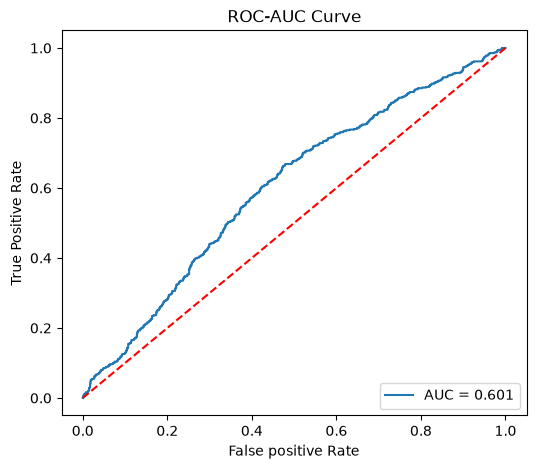

ROC-AUC Score: 0.6010276186638447


In [129]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_gb_tuned = gb_tuned.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_gb_tuned)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### Random Forest Hyperparameter Tuning

In [130]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Base Model
rf = RandomForestClassifier(random_state=42)

# Hyperparameter Grid
param_dist = {
    'n_estimators': [200, 300, 500, 700, 1000],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# Randomized Search
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_rf.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search_rf.best_params_)
print("Best ROC-AUC Score:", random_search_rf.best_score_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'criterion': 'gini', 'bootstrap': True}
Best ROC-AUC Score: 0.5952295957284516


#### Tuned Random Forest Model Training

In [131]:
rf_tuned = RandomForestClassifier (
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=5,
    criterion='gini',
    bootstrap=True,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

#### Prediction using Tuned Random Forest Model

In [132]:
y_pred_rf_tuned = rf_tuned.predict(X_test)

#### Tuned Random Forest Model Evaluation

Accuracy Score: 0.7255


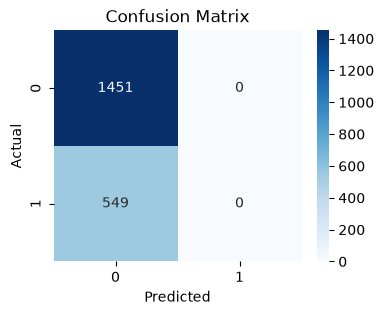


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [133]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
cr_rf_tuned = classification_report(y_test, y_pred_rf_tuned, zero_division=0)

# Accuracy
print("Accuracy Score:", as_rf_tuned)

# Confuaion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_rf_tuned)

#### Tuned Random Forest ROC-AUC Curve

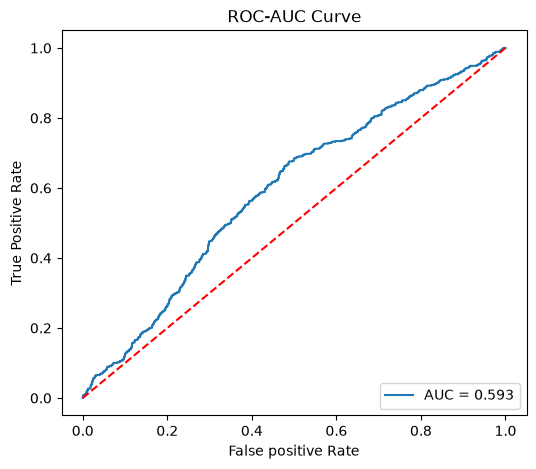

ROC-AUC Score: 0.5933556281140198


In [134]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_rf_tuned)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### AdaBoost Hyperparameter Tuning

In [135]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier

# Base Model
adb = AdaBoostClassifier(
    random_state=42
)

# Hyperparameter Grid
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700, 1000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
}

# Randomized Search
random_search_adb = RandomizedSearchCV(
    estimator=adb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_adb.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search_adb.best_params_)
print("Best ROC-AUC Score:", random_search_adb.best_score_)

Best Parameters: {'n_estimators': 300, 'learning_rate': 1.0}
Best ROC-AUC Score: 0.596394355453852


#### Tuned AdaBoost Model Training

In [136]:
adb_tuned = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=1.0,
    random_state=42
)

adb_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](300,)","[0.29,0.47,0.48,...,0.5 ,0.5 ,0.5 ]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](300,)","[0.91,0.13,0.1 ,...,0.01,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0.09,0.02,0.06,...,0.08,0.2 ,0.03]"


#### Tuned AdaBoost Prediction

In [137]:
y_pred_adb_tuned = adb_tuned.predict(X_test)

#### Tuned AdaBoost Model EvaluationTuned

Accuracy Score: 0.7255


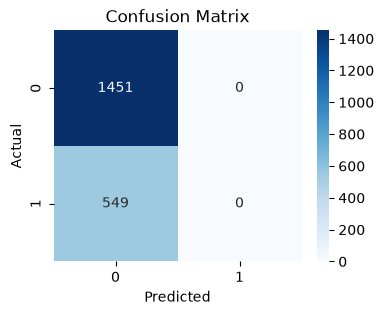


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.00      0.00      0.00       549

    accuracy                           0.73      2000
   macro avg       0.36      0.50      0.42      2000
weighted avg       0.53      0.73      0.61      2000



In [138]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_adb_tuned = accuracy_score(y_test, y_pred_adb_tuned)
cm_adb_tuned = confusion_matrix(y_test, y_pred_adb_tuned)
cr_adb_tuned = classification_report(y_test, y_pred_adb_tuned, zero_division=0)

# Accuracy
print("Accuracy Score:", as_adb_tuned)

# Confuaion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_adb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_adb_tuned)

#### Tuned AdaBoost Model Evaluation

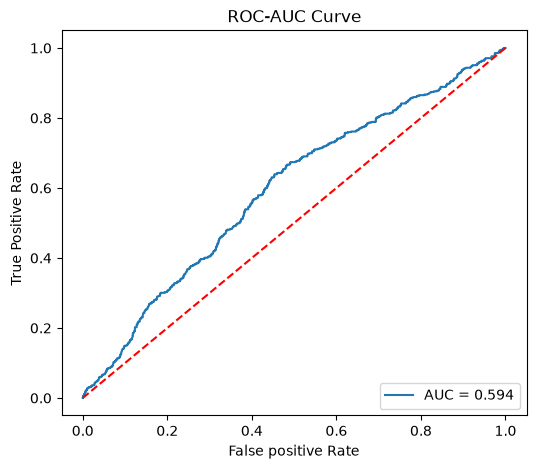

ROC-AUC Score: 0.5943617805194332


In [139]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_adb_tuned = adb_tuned.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_adb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_adb_tuned)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### Gaussian Naive Bayes Hyperparameter Tuning

In [140]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Base Model
gnb = GaussianNB()

# Hyperparameter Grid
param_dist = {
    'var_smoothing': np.logspace(0, -12, 200)
}

# Randomized Search
random_search_gnb = RandomizedSearchCV(
    estimator=gnb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Fit
random_search_gnb.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", random_search_gnb.best_params_)
print("Best ROC-AUC Score:", random_search_gnb.best_score_)

Best Parameters: {'var_smoothing': np.float64(1.0969857978923841e-08)}
Best ROC-AUC Score: 0.5884649122807017


#### Tuned Gaussian Naive Bayes Model Training

In [141]:
gnb_tuned = GaussianNB(
    var_smoothing=1.0969857978923841e-08
)

gnb_tuned.fit(X_train, y_train)

,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1.0969857978923841e-08
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[5700.,2300.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.71,0.29]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.1355
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Age','JobLevel','YearsAtCompany',...,'Department_Marketing', 'Department_Operations','Department_Sales']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 13)","[[37.77, 2.38, 7.75,..., 0.13, 0.17, 0.23], [37.68, 2.4 , 7.79,..., 0.08, 0.1 , 0.3 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 13)","[[87.57, 1.44,49.09,..., 0.25, 0.28, 0.31], [88.71, 1.47,48.99,..., 0.21, 0.23, 0.35]]"


#### Tuned Gaussian Naive Bayes Prediction

In [142]:
y_pred_gnb_tuned = gnb_tuned.predict(X_test)

#### Tuned Gaussian Naive Bayes Model Evaluation

Accuracy Score: 0.726


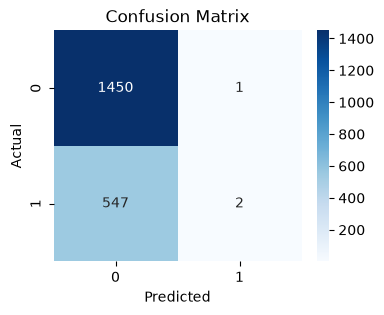


Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84      1451
           1       0.67      0.00      0.01       549

    accuracy                           0.73      2000
   macro avg       0.70      0.50      0.42      2000
weighted avg       0.71      0.73      0.61      2000



In [143]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gnb_tuned = accuracy_score(y_test, y_pred_gnb_tuned)
cm_gnb_tuned = confusion_matrix(y_test, y_pred_gnb_tuned)
cr_gnb_tuned = classification_report(y_test, y_pred_gnb_tuned)

# Accuracy
print("Accuracy Score:", as_gnb_tuned)

# Confuaion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm_gnb_tuned, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gnb_tuned)

#### Tuned Gaussian Naive Bayes ROC-AUC Curve

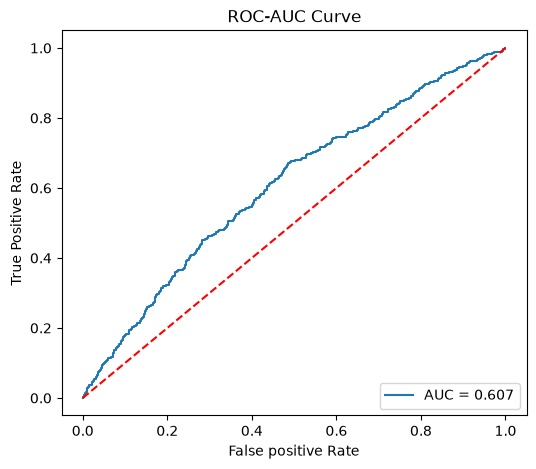

ROC-AUC Score: 0.6067984017052495


In [144]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive class
y_prob_gnb_tuned = gnb_tuned.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gnb_tuned)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_gnb_tuned)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### Final Comparison of Tuned Classification Models

In [145]:
# Classification Report Dictionary
cr_cb_tuned_dict = classification_report(y_test, y_pred_cb_tuned, output_dict=True, zero_division=0)
cr_gb_tuned_dict = classification_report(y_test, y_pred_gb_tuned, output_dict=True, zero_division=0)
cr_rf_tuned_dict = classification_report(y_test, y_pred_rf_tuned, output_dict=True, zero_division=0)
cr_adb_tuned_dict = classification_report(y_test, y_pred_adb_tuned, output_dict=True, zero_division=0)
cr_gnb_tuned_dict = classification_report(y_test, y_pred_gnb_tuned, output_dict=True, zero_division=0)

final_comparison = pd.DataFrame ({
    'Model': [
        "CatBoost",
        "Gradient Boosting",
        "Random Forest",
        "AdaBoost",
        "Gaussian NB"
    ],
    'Accuracy': [
        as_cb_tuned,
        as_gb_tuned,
        as_rf_tuned,
        as_adb_tuned,
        as_gnb_tuned
    ],
    'Precision': [
        cr_cb_tuned_dict["weighted avg"]["precision"],
        cr_gb_tuned_dict["weighted avg"]["precision"],
        cr_rf_tuned_dict["weighted avg"]["precision"],
        cr_adb_tuned_dict["weighted avg"]["precision"],
        cr_gnb_tuned_dict["weighted avg"]["precision"]
    ],
    'Recall': [
        cr_cb_tuned_dict["weighted avg"]["recall"],
        cr_gb_tuned_dict["weighted avg"]["recall"],
        cr_rf_tuned_dict["weighted avg"]["recall"],
        cr_adb_tuned_dict["weighted avg"]["recall"],
        cr_gnb_tuned_dict["weighted avg"]["recall"]
    ],
    'F1-Score': [
        cr_cb_tuned_dict["weighted avg"]["f1-score"],
        cr_gb_tuned_dict["weighted avg"]["f1-score"],
        cr_rf_tuned_dict["weighted avg"]["f1-score"],
        cr_adb_tuned_dict["weighted avg"]["f1-score"],
        cr_gnb_tuned_dict["weighted avg"]["f1-score"]
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_cb_tuned),
        roc_auc_score(y_test, y_prob_gb_tuned),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_adb_tuned),
        roc_auc_score(y_test, y_prob_gnb_tuned)
    ]
})

final_comparison = final_comparison.sort_values(by="ROC-AUC", ascending=False).round(4)
final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
4,Gaussian NB,0.7260,0.7098,0.7260,0.6122,0.6068
1,Gradient Boosting,0.7255,0.5264,0.7255,0.6101,0.6010
3,AdaBoost,0.7255,0.5264,0.7255,0.6101,0.5944
2,Random Forest,0.7255,0.5264,0.7255,0.6101,0.5934
0,CatBoost,0.7255,0.5264,0.7255,0.6101,0.5920


In [146]:
comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
9,GNB,0.6215,0.6512,0.6215,0.6335,0.6041
3,Gradient Boosting,0.7255,0.6641,0.7255,0.6129,0.5962
0,Logistic Regression,0.7255,0.5264,0.7255,0.6101,0.5943
10,AdaBoost,0.7255,0.5264,0.7255,0.6101,0.5917
6,CatBoost,0.7290,0.6939,0.7290,0.6309,0.5875
5,LightGBM,0.7195,0.6294,0.7195,0.6217,0.5743
4,XGBoost,0.6935,0.6237,0.6935,0.6375,0.5680
2,Random Forest,0.7070,0.6354,0.7070,0.6408,0.5534
7,KNN,0.6635,0.6110,0.6635,0.6287,0.5454
8,SVM,0.7255,0.5264,0.7255,0.6101,0.5437


### Final Model Selection - XGBoost Tuned Classifier

In [147]:
final_model_df = pd.DataFrame({
    "Model": ["Gaussian NB Tuned"],
    "Accuracy": [as_gnb_tuned],
    "Precision": [cr_gnb_tuned_dict["weighted avg"]["precision"]],
    "Recall": [cr_gnb_tuned_dict["weighted avg"]["recall"]],
    "F1-Score": [cr_gnb_tuned_dict["weighted avg"]["f1-score"]],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_gnb_tuned)]
})

final_model_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gaussian NB Tuned,0.726,0.7098,0.726,0.6122,0.6068


###### Gaussian Naive Bayes was selected as the final model because it achieved the best overall performance after hyperparameter tuning. It obtained the highest Accuracy (72.60%), Precision (70.98%), F1-Score (61.22%), and ROC-AUC Score (60.68%) among all the evaluated models. Therefore, it was chosen as the final model for deployment.

#### Gaussian NB Tuned Model Overfitting and Underfitting Check

In [148]:
print("Train Score:", gnb_tuned.score(X_train, y_train))
print("Test Score:", gnb_tuned.score(X_test, y_test))

Train Score: 0.711
Test Score: 0.726


###### The final Gaussian Naive Bayes model achieved a training accuracy of 71.1% and a testing accuracy of 72.6%. The small difference between the training and testing accuracy indicates that the model generalizes well to unseen data and does not show significant overfitting.

#### Feature Importance using Permutation Importance

In [149]:
from sklearn.inspection import permutation_importance

# Permutation Importance
result = permutation_importance(
    gnb_tuned,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

# DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

# Sort
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,Department_Finance,0.027876
10,Department_Marketing,0.019499
11,Department_Operations,0.017073
3,MonthlyIncome,0.009275
12,Department_Sales,0.007760
9,Department_IT,0.004743
8,Department_HR,0.003912
1,JobLevel,0.001643
2,YearsAtCompany,0.000744
6,DistanceFromHome,-0.000913


#### Top 10 Features Plot

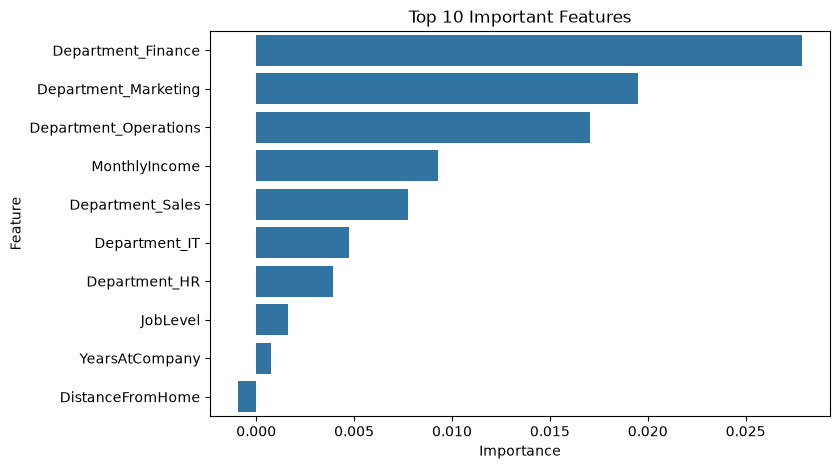

In [150]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

###### Gaussian Naive Bayes does not provide a built-in feature_importances_ attribute. Therefore, Permutation Importance was used to estimate the contribution of each feature by measuring the decrease in model performance after randomly shuffling feature values.

#### Final Model Misclassification Analysis

In [151]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gnb_tuned)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 1450
False Positives: 1
False Negatives: 547
True Positives : 2


#### Save the Final Gaussian Naive Bayes Model

In [152]:
import joblib

joblib.dump(gnb_tuned, "gnb_final_model.pkl")

print("Final Model saved successfully")

Final Model saved successfully


#### Save Feature Columns

In [153]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature Columns Saved Successfully")

Feature Columns Saved Successfully
